## What is GraphQL?

GraphQL is a query language + runtime for APIs developed by Meta Platforms.

<br> **Note**: *Runtime = the engine on the server that actually executes your query*
<br>
<br> Instead of hitting multiple endpoints (like REST), we send one query and specify exactly what data we need.

| Feature               | GraphQL                           | REST                                      |
| --------------------- | --------------------------------- | ----------------------------------------- |
| **Data Fetching**     | Client decides what data to fetch | Server decides response structure         |
| **Endpoints**         | Single endpoint (`/graphql`)      | Multiple endpoints (`/users`, `/courses`) |
| **Over-fetching**     | ❌ No (only required data)         |  Common issue                            |
| **Under-fetching**    | ❌ No                              |  Common issue    |
| **Flexibility**       | Highly flexible queries           | Fixed response                            |
| **Performance**       | Efficient (less data transfer)    | Can be inefficient                        |
| **Learning Curve**    | Higher                            | Easier                                    |
| **Error Handling**    | Structured errors in response     | HTTP status codes                         |
| **Tooling**           | Strong (GraphiQL, Apollo)         | Standard tools (Postman)                  |


## Structure of a GraphQL query

A GraphQL query has 3 main parts:

Root field
<br> Arguments if needed
<br> Selected fields

**example**
```graphql
query {
  planet(planetID: 1) {
    name
    diameter
    rotationPeriod
  }
}
```

planet → **root** field
<br> planetID: 1 → **argument**
<br> name, diameter, rotationPeriod → **selected fields**

**If we want to practice graphql then use** https://graphql.org/swapi-graphq

### Root field

A root field is the main entry point from which we start asking data.
<br> But root fields are not enough by themselves.
<br> Some root fields need arguments.

### Arguments
Arguments are values you pass to a field to tell GraphQL which record you want.

For planet, the API expects either id or planetID.

```graphql
query {
  planet(planetID: 1) {
    name
    diameter
    rotationPeriod
  }
}```

### Fields

Fields are the actual pieces of data we want back.

In above, we want name, diameter and rotationPeriod in response


### Step-by-step method to read docs

**Step 1:** **Find the root field in Query docs**


For vehicles, possible root fields can be:

<br> vehicle
<br> allVehicles

Now apply logic:

If I want one record → likely vehicle
<br>If I want many records → likely allVehicles

**step2**: **Check whether the root field needs arguments**

 **A)**
<br> ```vehicle(id: ID, vehicleID: ID): Vehicle```

**root field name** = vehicle
<br> **arguments** = id or vehicleID
<br> **return type** = Vehicle


*This returns one Vehicle*

```graphql 
query {
  vehicle(vehicleID: 4) {
    name
    model
  }
}
```

 **B)**
<br> `allVehicles: VehiclesConnection`



**root field name** = allVehicles
<br>**no argument required**
<br>**return type** = VehiclesConnection

Now apply logic:

<br>this is not returning one Vehicle directly
<br>it is returning a wrapper type called VehiclesConnection

**Step 3: Open the return type**

go to **root** and we will find *allVehicles* and *vehicle*
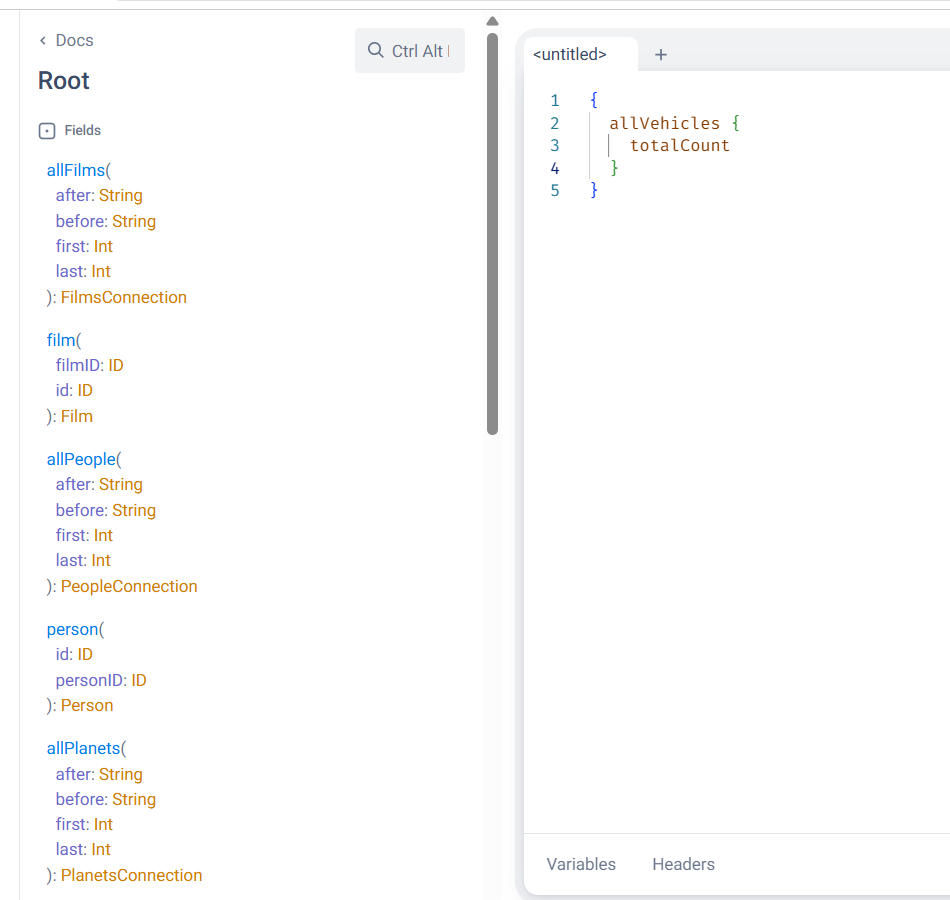

If allVehicles returns VehiclesConnection, click that type.

Then we may see fields like:

<br>vehicles
<br>pageInfo
<br>totalCount
<br>edges

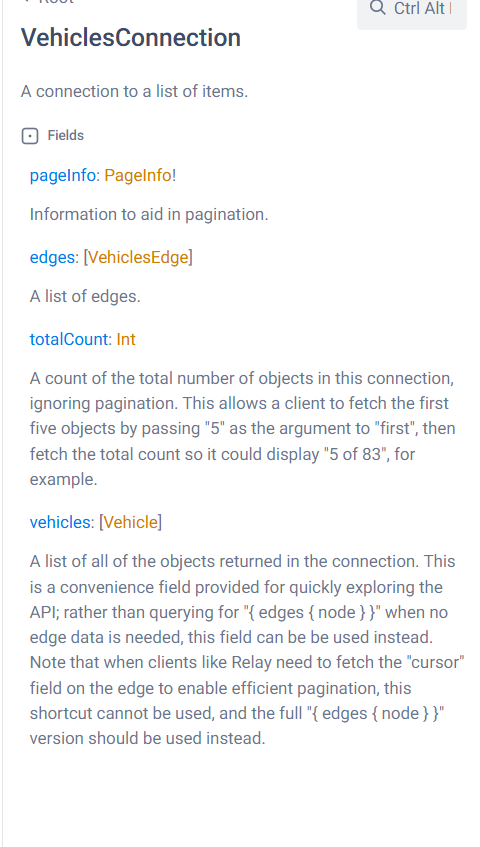

### <font color="blue">  vehicles: [Vehicle] </font>


returns all vehicle records available

```graphql
query {
  allVehicles {
    vehicles {
      name
      model
    }
  }
}
```

### <font color="blue">  totalCount: Int </font>



“How many total vehicle records exist in this collection?”

```graphql
query {
  allVehicles {
    totalCount
  }
}
```

if we want data with total counts then:
```graphql
query {
  allVehicles {
    totalCount
    vehicles {
      name
    }
  }
}
```

### <font color="blue">  PageInfo </font>

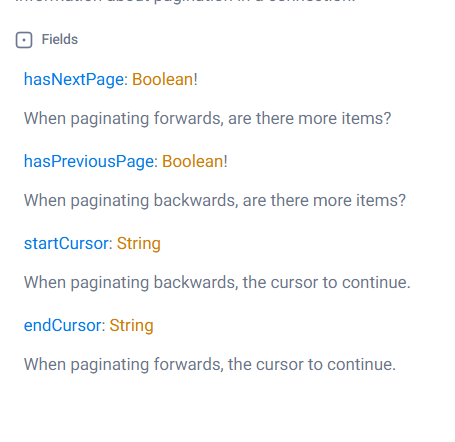

**Before moving to Pageinfo, lets cover important parameters**

#### <font color="Purple">  A. first: Int </font>


give me the first N records from the current position

 ``` graphql
query {
  allVehicles(first: 3) {
    vehicles {
      name
    }
  }
} 

#### <font color="Purple">  B. last: Int </font>

<br> give me the last N records from the current position
``` graphql query {
  allVehicles(last: 3) {
    vehicles {
      name
    }
  }
}


#### <font color="Purple">  C. after: String </font>
start after this cursor
```graphql
query {
  allVehicles(first: 3, after: "CURSOR_VALUE") {
    vehicles {
      name
    }
  }
}

#### <font color="Purple">  D. before: String </font>
return records before this cursor
```graphql
query {
  allVehicles(last: 3, before: "CURSOR_VALUE") {
    vehicles {
      name
    }
  }
}

**hasNextPage**

if I move forward from this current page, are more records available?

```graphql


query {
  allVehicles(first: 3) {
    vehicles {
      name
    }
    pageInfo {
      hasNextPage
    }
  }
}

**hasPreviousPage**

if I move backward from this current page, are records available before it?



```graphql
query {
  allVehicles(last: 3) {
    vehicles {
      name
    }
    pageInfo {
      hasPreviousPage
    }
  }
}

**startcursor and endcursor**

cursor of the first and last record in the current returned page


``` graphql
query {
  allVehicles(last: 3) {
    vehicles {
      name
    }
    pageInfo {
      startCursor
      endCursor
    }
  }
}

### Full forward pagination flow

**Step1**

First fetch 3 records with endcursor, we can use endcursor in next batch if hasnextpage is true

```graphql
query {
  allVehicles(first: 3) {
    vehicles {
      name
    }
    pageInfo {
      hasNextPage
      endCursor
    }
  }
}

**step2**

Suppose response gives:

hasNextPage = true
endCursor = "YXJyYXljb25uZWN0aW9uOjI="

<br> **start after record 3
fetch next 3**

``` graphql
query {
  allVehicles(first: 3, after: "YXJyYXljb25uZWN0aW9uOjI=") {
    vehicles {
      name
    }
    pageInfo {
      hasNextPage
      endCursor
    }
  }
}

**Step 3**

Repeat until:

"hasNextPage": false